# Energy Overload Prediction – Data Analysis & Machine Learning

This project analyzes and predicts energy overload scenarios using real-world smart grid data from ISO New England (ISONE).

The goal is to understand energy consumption patterns, explore key drivers of demand, and identify potential overload conditions through data analysis and predictive modeling.

## 1. Import libraries


In [31]:
#data manipulation
import pandas as pd
import numpy as np

#visualisation
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)

#machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score

## 2. Data loading and data Overview

In [32]:
df = pd.read_csv('/content/sample_data/smart_city_energy_dataset.csv')
# To display the top 5 rows
df.head(5)

,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
0,2021-01-01 00:00:00,0,4,0,0,1,53,1,192.976646,0,...,ZoneA,35.009842,-105.518617,225.154387,0.599292,Suburban,209.578166,116.667293,92.910873,0
1,2021-01-01 00:30:00,0,4,0,0,2,53,1,709.417292,0,...,ZoneB,37.067136,-120.634755,556.305113,6.022215,Urban,711.329436,40.603240,670.726196,0
2,2021-01-01 01:00:00,1,4,0,0,2,53,1,441.323762,0,...,ZoneB,39.952764,-114.198386,432.500561,0.311498,Suburban,434.571941,45.235566,389.336376,0
3,2021-01-01 01:30:00,1,4,0,0,1,53,1,110.061053,0,...,ZoneA,44.179765,-78.504895,12.658897,2.689435,Urban,119.913430,216.133025,-96.219595,1
4,2021-01-01 02:00:00,2,4,0,0,2,53,1,741.130717,0,...,ZoneA,29.232799,-74.472891,477.191782,6.382530,Rural,747.746618,320.609219,427.137399,0


In [33]:
df.shape

(72960, 60)

In [34]:
df.columns.tolist()

['Timestamp',
 'Hour of Day',
 'Day of Week',
 'Is Weekend',
 'Is Holiday',
 'Season',
 'Week of Year',
 'Month',
 'Historical Electricity Load (kW)',
 'Peak Load Indicator',
 'Load Sector Type',
 'Transformer Load Level',
 'Voltage Level (V)',
 'Current Level (A)',
 'Power Factor',
 'Substation ID / Region ID',
 'Demand Response Signal (Binary)',
 'Grid Frequency (Hz)',
 'Solar PV Output (kW)',
 'Wind Power Output (kW)',
 'Solar Panel Temperature (°C)',
 'Wind Speed (m/s)',
 'Wind Direction (degrees)',
 'Inverter Efficiency (%)',
 'Battery State of Charge (SOC) (%)',
 'Battery Discharge Rate (kW/h)',
 'Renewable Forecast Error',
 'Curtailment Event Flag',
 'Temperature (°C)',
 'Humidity (%)',
 'Solar Irradiance (W/m²)',
 'Cloud Cover (%)',
 'Rainfall (mm)',
 'Snowfall (mm)',
 'Visibility (km)',
 'Weather Condition',
 'Atmospheric Pressure (hPa)',
 'Dew Point (°C)',
 'Smart Meter Reading per Building (kW)',
 'Building Type (Encoded)',
 'Building Occupancy Rate (%)',
 'Public Transit Op

In [35]:
df.tail(5)

,Timestamp,Hour of Day,Day of Week,Is Weekend,Is Holiday,Season,Week of Year,Month,Historical Electricity Load (kW),Peak Load Indicator,...,Region/Zone ID,Latitude,Longitude,Altitude (m),Distance to Nearest Substation (km),Area Type,Electricity Load,Renewable Energy Load,Net Load,Curtailment Risk / Surplus Flag
72955,2025-02-28 21:30:00,21,4,0,0,0,9,2,1154.906905,1,...,ZoneA,31.525056,-88.889488,63.132776,13.293000,Urban,1142.603466,202.726976,939.876490,0
72956,2025-02-28 22:00:00,22,4,0,0,2,9,2,669.178826,0,...,ZoneA,37.203144,-65.508336,40.796600,5.163879,Urban,659.927979,108.389860,551.538118,0
72957,2025-02-28 22:30:00,22,4,0,0,1,9,2,291.109390,0,...,ZoneB,40.075869,-91.117936,197.052846,0.941415,Rural,263.325648,65.845250,197.480398,0
72958,2025-02-28 23:00:00,23,4,0,0,0,9,2,270.818673,0,...,ZoneC,43.936743,-111.190549,58.234538,2.141497,Suburban,294.873612,3.212133,291.661479,0
72959,2025-02-28 23:30:00,23,4,0,0,1,9,2,474.315116,0,...,ZoneA,33.378651,-102.646486,37.630548,3.783281,Urban,446.018371,177.182424,268.835947,0


In [36]:
df.dtypes

,0
Timestamp,object
Hour of Day,int64
Day of Week,int64
Is Weekend,int64
Is Holiday,int64
Season,int64
Week of Year,int64
Month,int64
Historical Electricity Load (kW),float64
Peak Load Indicator,int64


## 3. Data Cleaning
We handle missing values, remove irrelevant features, and ensure data consistency



In [37]:

df_original = df.copy()

columns_to_keep = [
'Timestamp',
'Substation ID / Region ID',
'Region/Zone ID',
'Building Type (Encoded)',
'Smart Meter Reading per Building (kW)',
'Electricity Load',
'Transformer Load Level',
'Temperature (°C)',
'Humidity (%)',
'Solar Irradiance (W/m²)',
'EV Charging Station Load (kW)',
'Building Occupancy Rate (%)',
'Solar PV Output (kW)',
'Wind Power Output (kW)'
]

df_clean = df[columns_to_keep]

In [38]:
df_clean.isnull().sum()

,0
Timestamp,0
Substation ID / Region ID,0
Region/Zone ID,0
Building Type (Encoded),0
Smart Meter Reading per Building (kW),0
Electricity Load,0
Transformer Load Level,0
Temperature (°C),0
Humidity (%),0
Solar Irradiance (W/m²),0


In [39]:
(df_clean.isnull().sum() / len(df_clean) * 100).sort_values(ascending=False)

,0
Timestamp,0.0
Substation ID / Region ID,0.0
Region/Zone ID,0.0
Building Type (Encoded),0.0
Smart Meter Reading per Building (kW),0.0
Electricity Load,0.0
Transformer Load Level,0.0
Temperature (°C),0.0
Humidity (%),0.0
Solar Irradiance (W/m²),0.0


In [40]:
# Filtering residential
df_residential = df_clean[df_clean['Building Type (Encoded)'] == 1]
df_residential.shape

(21991, 14)

##4. EDA

In [41]:
df_residential['Timestamp'] = pd.to_datetime(df_residential['Timestamp'])
df_residential['hour'] = df_residential['Timestamp'].dt.hour
df_residential['date'] = df_residential['Timestamp'].dt.date
df_residential.head()

/tmp/ipykernel_15264/4272612811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_residential['Timestamp'] = pd.to_datetime(df_residential['Timestamp'])
/tmp/ipykernel_15264/4272612811.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_residential['hour'] = df_residential['Timestamp'].dt.hour
/tmp/ipykernel_15264/4272612811.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,Timestamp,Substation ID / Region ID,Region/Zone ID,Building Type (Encoded),Smart Meter Reading per Building (kW),Electricity Load,Transformer Load Level,Temperature (°C),Humidity (%),Solar Irradiance (W/m²),EV Charging Station Load (kW),Building Occupancy Rate (%),Solar PV Output (kW),Wind Power Output (kW),hour,date
1,2021-01-01 00:30:00,R1,ZoneB,1,5.110605,711.329436,92.567902,36.734599,5.300440,18.781034,4.710542,87.022515,9.158357,31.444883,0,2021-01-01
4,2021-01-01 02:00:00,R1,ZoneA,1,0.775192,747.746618,71.965473,13.782261,12.330477,605.363264,26.055437,98.299938,12.410062,308.199156,2,2021-01-01
6,2021-01-01 03:00:00,R1,ZoneA,1,0.360452,800.348579,47.190791,24.890056,8.729796,289.312287,4.875903,87.374014,14.415363,35.956069,3,2021-01-01
7,2021-01-01 03:30:00,R1,ZoneA,1,2.455928,428.743623,38.931465,12.972487,12.203597,702.979990,37.338888,75.004308,47.660308,7.685904,3,2021-01-01
11,2021-01-01 05:30:00,R2,ZoneA,1,0.213743,134.884344,69.655736,31.855181,51.683315,701.817563,20.994039,43.874791,44.564024,37.295321,5,2021-01-01


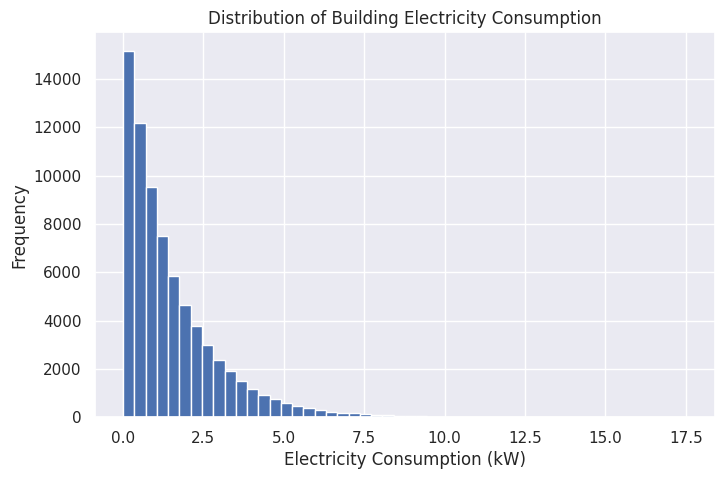

In [42]:
#histogram
plt.figure(figsize=(8,5))
plt.hist(df_clean['Smart Meter Reading per Building (kW)'], bins=50)
plt.title("Distribution of Building Electricity Consumption")
plt.xlabel("Electricity Consumption (kW)")
plt.ylabel("Frequency")
plt.show()

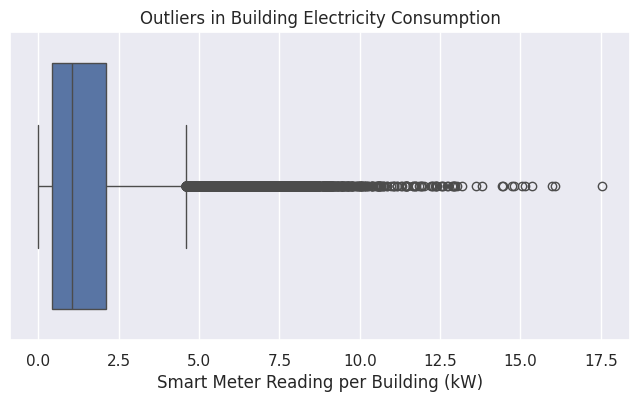

In [43]:
#boxplot

plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean['Smart Meter Reading per Building (kW)'])
plt.title("Outliers in Building Electricity Consumption")
plt.show()

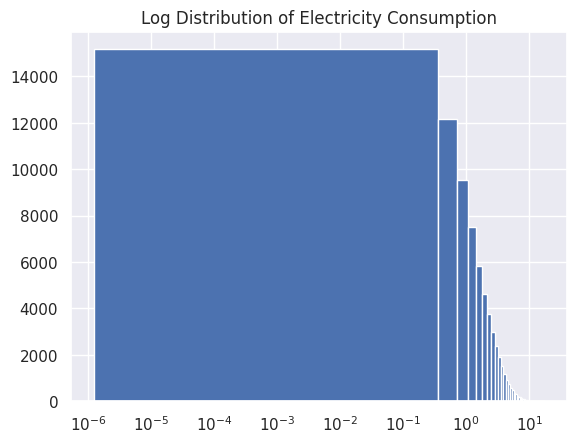

In [44]:

plt.hist(df_clean['Smart Meter Reading per Building (kW)'], bins=50)
plt.xscale('log')
plt.title("Log Distribution of Electricity Consumption")
plt.show()

## 5. Detect potential outliers with IQR

In [45]:
Q1 = df_clean['Smart Meter Reading per Building (kW)'].quantile(0.25)
Q3 = df_clean['Smart Meter Reading per Building (kW)'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [46]:
outliers = df_clean[
(df_clean['Smart Meter Reading per Building (kW)'] < lower) |
(df_clean['Smart Meter Reading per Building (kW)'] > upper)
]

In [47]:
len(outliers)

3441

In [48]:
outliers[['Timestamp','Substation ID / Region ID','Smart Meter Reading per Building (kW)']].head()

,Timestamp,Substation ID / Region ID,Smart Meter Reading per Building (kW)
1,2021-01-01 00:30:00,R1,5.110605
13,2021-01-01 06:30:00,R1,7.717056
23,2021-01-01 11:30:00,R1,6.610598
61,2021-01-02 06:30:00,R1,5.051520
63,2021-01-02 07:30:00,R2,4.886296


In [49]:
len(outliers) / len(df_clean) * 100

4.7162828947368425

In [50]:
df_clean['Smart Meter Reading per Building (kW)'].describe()

,Smart Meter Reading per Building (kW)
count,72960.000000
mean,1.503317
std,1.506260
min,0.000001
25%,0.431329
50%,1.036973
75%,2.096204
max,17.530333


## 6. Aggregate residential load by substation and timestamp

In [51]:

load_substation = df_residential.groupby(
    ['Timestamp','Substation ID / Region ID','Temperature (°C)', 'Humidity (%)', 'Solar Irradiance (W/m²)', 'EV Charging Station Load (kW)', 'Building Occupancy Rate (%)']
)['Smart Meter Reading per Building (kW)'].sum().reset_index()

load_substation = load_substation.rename(
    columns={'Smart Meter Reading per Building (kW)': 'residential_load_kw'}
)

load_substation.head()

,Timestamp,Substation ID / Region ID,Temperature (°C),Humidity (%),Solar Irradiance (W/m²),EV Charging Station Load (kW),Building Occupancy Rate (%),residential_load_kw
0,2021-01-01 00:30:00,R1,36.734599,5.300440,18.781034,4.710542,87.022515,5.110605
1,2021-01-01 02:00:00,R1,13.782261,12.330477,605.363264,26.055437,98.299938,0.775192
2,2021-01-01 03:00:00,R1,24.890056,8.729796,289.312287,4.875903,87.374014,0.360452
3,2021-01-01 03:30:00,R1,12.972487,12.203597,702.979990,37.338888,75.004308,2.455928
4,2021-01-01 05:30:00,R2,31.855181,51.683315,701.817563,20.994039,43.874791,0.213743


## 7. Estimate substation capacity with the 95th percentile

In [52]:

capacity = load_substation.groupby(
    'Substation ID / Region ID'
)['residential_load_kw'].quantile(0.95)

capacity.head()

,residential_load_kw
Substation ID / Region ID,
R1,4.469801
R2,4.432320
R3,4.349940
R4,4.286699


In [53]:
load_substation['capacity_kw'] = load_substation['Substation ID / Region ID'].map(capacity)
load_substation.head()

,Timestamp,Substation ID / Region ID,Temperature (°C),Humidity (%),Solar Irradiance (W/m²),EV Charging Station Load (kW),Building Occupancy Rate (%),residential_load_kw,capacity_kw
0,2021-01-01 00:30:00,R1,36.734599,5.300440,18.781034,4.710542,87.022515,5.110605,4.469801
1,2021-01-01 02:00:00,R1,13.782261,12.330477,605.363264,26.055437,98.299938,0.775192,4.469801
2,2021-01-01 03:00:00,R1,24.890056,8.729796,289.312287,4.875903,87.374014,0.360452,4.469801
3,2021-01-01 03:30:00,R1,12.972487,12.203597,702.979990,37.338888,75.004308,2.455928,4.469801
4,2021-01-01 05:30:00,R2,31.855181,51.683315,701.817563,20.994039,43.874791,0.213743,4.432320


## 8. Capacity margin and utilization

- **capacity_margin_kw** = estimated substation capacity - current load
- **utilization_ratio** = current load / capacity

In [54]:
load_substation['capacity_margin_kw'] = (
    load_substation['capacity_kw'] - load_substation['residential_load_kw']
)

load_substation['utilization_ratio'] = (
    load_substation['residential_load_kw'] / load_substation['capacity_kw']
)

load_substation.head()

,Timestamp,Substation ID / Region ID,Temperature (°C),Humidity (%),Solar Irradiance (W/m²),EV Charging Station Load (kW),Building Occupancy Rate (%),residential_load_kw,capacity_kw,capacity_margin_kw,utilization_ratio
0,2021-01-01 00:30:00,R1,36.734599,5.300440,18.781034,4.710542,87.022515,5.110605,4.469801,-0.640805,1.143363
1,2021-01-01 02:00:00,R1,13.782261,12.330477,605.363264,26.055437,98.299938,0.775192,4.469801,3.694609,0.173429
2,2021-01-01 03:00:00,R1,24.890056,8.729796,289.312287,4.875903,87.374014,0.360452,4.469801,4.109349,0.080642
3,2021-01-01 03:30:00,R1,12.972487,12.203597,702.979990,37.338888,75.004308,2.455928,4.469801,2.013873,0.549449
4,2021-01-01 05:30:00,R2,31.855181,51.683315,701.817563,20.994039,43.874791,0.213743,4.432320,4.218577,0.048224


In [55]:

load_substation['capacity'] = load_substation[
'Substation ID / Region ID'
].map(capacity)

## 9. Detect overload events

In [56]:

load_substation['overload_ratio'] = (
    load_substation['residential_load_kw'] - load_substation['capacity_kw']
) / load_substation['capacity_kw']


In [57]:
#when substation is overload
load_substation['overload'] = load_substation['overload_ratio'] > 0

load_substation[['Timestamp', 'Substation ID / Region ID', 'residential_load_kw', 'capacity_kw', 'capacity_margin_kw', 'utilization_ratio', 'overload']].head()

,Timestamp,Substation ID / Region ID,residential_load_kw,capacity_kw,capacity_margin_kw,utilization_ratio,overload
0,2021-01-01 00:30:00,R1,5.110605,4.469801,-0.640805,1.143363,True
1,2021-01-01 02:00:00,R1,0.775192,4.469801,3.694609,0.173429,False
2,2021-01-01 03:00:00,R1,0.360452,4.469801,4.109349,0.080642,False
3,2021-01-01 03:30:00,R1,2.455928,4.469801,2.013873,0.549449,False
4,2021-01-01 05:30:00,R2,0.213743,4.432320,4.218577,0.048224,False


In [58]:
#how much overload events?
load_substation['overload'].sum()

np.int64(1102)

## 10. Most critical substations

In [59]:

critical_substations=load_substation.groupby(
'Substation ID / Region ID'
)['overload'].sum().sort_values(ascending=False)

critical_substations.head(10)

,overload
Substation ID / Region ID,
R1,556
R2,331
R3,161
R4,54


In [60]:
margin_by_substation = load_substation.groupby(
    'Substation ID / Region ID'
)['capacity_margin_kw'].min().sort_values()

margin_by_substation.head(10)

,capacity_margin_kw
Substation ID / Region ID,
R2,-10.617120
R1,-9.132487
R3,-8.049326
R4,-4.837771


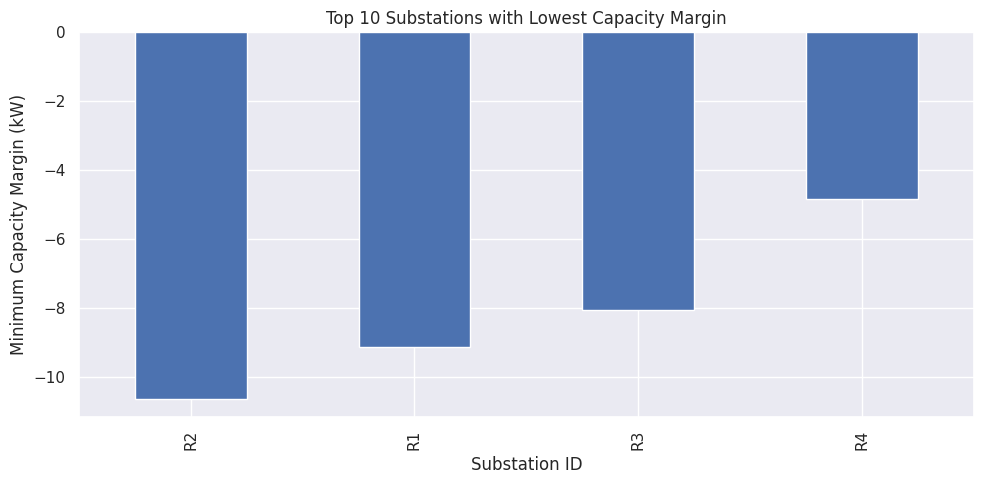

In [61]:
plt.figure(figsize=(10,5))
margin_by_substation.head(10).plot(kind='bar')
plt.title("Top 10 Substations with Lowest Capacity Margin")
plt.xlabel("Substation ID")
plt.ylabel("Minimum Capacity Margin (kW)")
plt.tight_layout()
plt.show()

## 11. Critical hours of the day

In [62]:

load_substation['hour'] = load_substation['Timestamp'].dt.hour
overload_by_hour = load_substation.groupby('hour')['overload'].sum()
overload_by_hour

,overload
hour,
0,46
1,32
2,44
3,46
4,56
5,55
6,55
7,51
8,47


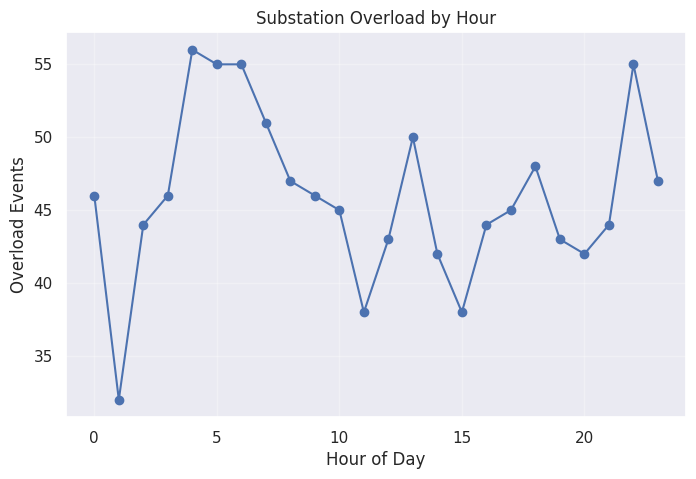

In [63]:
plt.figure(figsize=(8,5))
plt.plot(overload_by_hour.index, overload_by_hour.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Overload Events")
plt.title("Substation Overload by Hour")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Feature Engineering

Additional features were created to better capture temporal patterns, energy demand behavior, and infrastructure utilization dynamics.

The feature engineering process includes:
- Temporal and cyclical variables
- Substation utilization metrics
- Lag features based on historical energy behavior
- Environmental and urban activity variables
- Rolling and historical statistical indicators
- Substation clustering

In [64]:
#substation study
load_substation['overload'] = (load_substation['residential_load_kw'] > load_substation['capacity']).astype(int) #analizza se il carico supera la capacità della cabina
load_substation['near_overload'] = (load_substation['residential_load_kw'] / load_substation['capacity'] >= 0.90).astype(int) #misura la percentuale di utilizza della cabina

In [65]:
#cyclical variables
load_substation['hour'] = load_substation['Timestamp'].dt.hour
load_substation['day_of_week'] = load_substation['Timestamp'].dt.dayofweek
load_substation['month'] = load_substation['Timestamp'].dt.month
load_substation['is_weekend'] = (load_substation['day_of_week'] >= 5).astype(int)

load_substation['hour_sin'] = np.sin(2 * np.pi * load_substation['hour'] / 24)
load_substation['hour_cos'] = np.cos(2 * np.pi * load_substation['hour'] / 24)
load_substation['dow_sin'] = np.sin(2 * np.pi * load_substation['day_of_week'] / 7)
load_substation['dow_cos'] = np.cos(2 * np.pi * load_substation['day_of_week'] / 7)


In [66]:
#lag & rolling
load_substation = load_substation.sort_values(['Substation ID / Region ID', 'Timestamp']).copy()
group_col = 'Substation ID / Region ID'
load_col = 'residential_load_kw'

for lag in [1,2,3,6,12,24]:
    load_substation[f'load_lag_{lag}'] = load_substation.groupby(group_col)[load_col].shift(lag)

for window in [3,6,12,24]:
    load_substation[f'load_roll_mean_{window}'] = load_substation.groupby(group_col)[load_col].transform(lambda x: x.shift(1).rolling(window).mean())
    load_substation[f'load_roll_std_{window}'] = load_substation.groupby(group_col)[load_col].transform(lambda x: x.shift(1).rolling(window).std())
    load_substation[f'load_roll_max_{window}'] = load_substation.groupby(group_col)[load_col].transform(lambda x: x.shift(1).rolling(window).max())

In [67]:
load_substation['utilization'] = load_substation[load_col] / load_substation['capacity']
for lag in [1,2,3]:
    load_substation[f'utilization_lag_{lag}'] = load_substation.groupby(group_col)['utilization'].shift(lag)

features = [
    'hour','day_of_week','month','is_weekend',
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'Temperature (°C)','Humidity (%)','Solar Irradiance (W/m²)',
    'EV Charging Station Load (kW)','Building Occupancy Rate (%)'
]
features += [col for col in load_substation.columns if 'lag' in col or 'roll' in col or 'utilization' in col]

In [68]:
cluster_features = [
    'capacity','residential_load_kw','Temperature (°C)','Humidity (%)',
    'Solar Irradiance (W/m²)','EV Charging Station Load (kW)','Building Occupancy Rate (%)'
]
agg_df = load_substation.groupby('Substation ID / Region ID')[cluster_features].mean().reset_index()

if len(agg_df) < 2:
    agg_df['cluster'] = 0
else:
    n_clusters = min(5, len(agg_df))  # max 5 cluster
    scaler = StandardScaler()
    agg_scaled = scaler.fit_transform(agg_df[cluster_features])
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    agg_df['cluster'] = kmeans.fit_predict(agg_scaled)

load_substation = load_substation.merge(agg_df[['Substation ID / Region ID','cluster']], on='Substation ID / Region ID', how='left')

## 13. XGBoost Model
XGBoost was used as the main predictive model due to its strong performance on structured and tabular datasets.

In [69]:
def train_xgb_for_target(X_train, y_train):
    scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        reg_lambda=1.0, scale_pos_weight=scale_pos_weight,
        objective='binary:logistic', eval_metric='logloss', random_state=42
    )
    model.fit(X_train, y_train)
    return model

def threshold_search(y_true, proba, beta=2.0):
    rows = []
    thresholds = np.arange(0.10, 0.91, 0.05)
    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        rows.append({
            'threshold': t,
            'precision': precision_score(y_true, pred_t, zero_division=0),
            'recall': recall_score(y_true, pred_t, zero_division=0),
            'f1': f1_score(y_true, pred_t, zero_division=0),
            'f2': fbeta_score(y_true, pred_t, beta=beta, zero_division=0)
        })
    table = pd.DataFrame(rows)
    best_row = table.sort_values(['f2','recall','precision'], ascending=False).iloc[0]
    return table, float(best_row['threshold'])


In [70]:
cluster_models = {}
cluster_thresholds = {}

clusters = load_substation['cluster'].unique()
for c in clusters:
    cluster_df = load_substation[load_substation['cluster'] == c].sort_values('Timestamp')

    if len(cluster_df) < 10:

        continue

    split_idx = int(len(cluster_df) * 0.8)
    train_df = cluster_df.iloc[:split_idx]
    test_df = cluster_df.iloc[split_idx:]

    X_train = train_df[features]
    y_train = train_df['overload']
    X_test = test_df[features]
    y_test = test_df['overload']

    model = train_xgb_for_target(X_train, y_train)
    proba = model.predict_proba(X_test)[:,1]
    _, best_threshold = threshold_search(y_test, proba, beta=2.0)

    cluster_models[c] = model
    cluster_thresholds[c] = best_threshold
    print(f'Cluster {c}: best threshold = {best_threshold}')

Cluster 3: best threshold = 0.7500000000000002
Cluster 0: best threshold = 0.6000000000000002
Cluster 2: best threshold = 0.45000000000000007
Cluster 1: best threshold = 0.1


In [71]:
X_train_global = load_substation[features]
y_train_global = load_substation['overload']
global_model = train_xgb_for_target(X_train_global, y_train_global)
global_threshold = 0.5  # default

In [72]:
def predict_clustered(df):
    preds = []
    for _, row in df.iterrows():
        c = row['cluster']
        model = cluster_models.get(c, global_model)
        threshold = cluster_thresholds.get(c, global_threshold)
        proba = model.predict_proba(row[features].values.reshape(1,-1))[:,1][0]
        preds.append(int(proba >= threshold))
    return np.array(preds)

load_substation['pred_overload'] = predict_clustered(load_substation)

## 14. Model Evaluation

Model performance was evaluated using standard classification metrics:
- Accuracy
- Precision
- Recall
- F1-score
- F2-score

In [73]:
def predict_clustered(df):
    preds = []
    for _, row in df.iterrows():
        c = row['cluster']
        model = cluster_models.get(c, global_model)
        threshold = cluster_thresholds.get(c, global_threshold)
        proba = model.predict_proba(row[features].values.reshape(1,-1))[:,1][0]
        preds.append(int(proba >= threshold))
    return np.array(preds)

load_substation['pred_overload'] = predict_clustered(load_substation)


y_true = load_substation['overload']
y_pred = load_substation['pred_overload']

precision = precision_score(load_substation['overload'], load_substation['pred_overload'])
recall = recall_score(load_substation['overload'], load_substation['pred_overload'])
f1 = f1_score(load_substation['overload'], load_substation['pred_overload'])
f2 = fbeta_score(load_substation['overload'], load_substation['pred_overload'], beta=2)
accuracy = accuracy_score(y_true, y_pred)

print(f'Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}, F2: {f2:.3f}')

Accuracy: 1.000, Precision: 0.997, Recall: 0.998, F1: 0.998, F2: 0.998


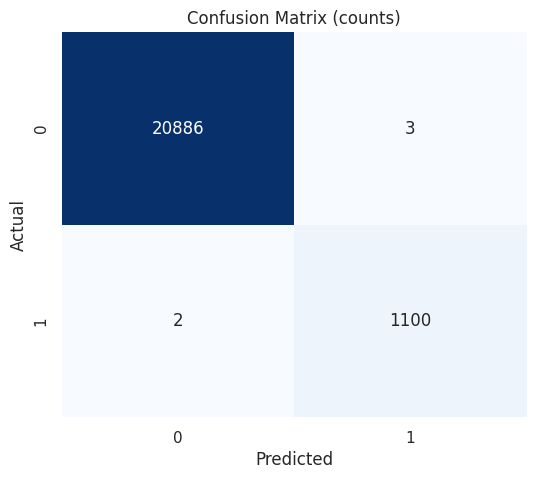

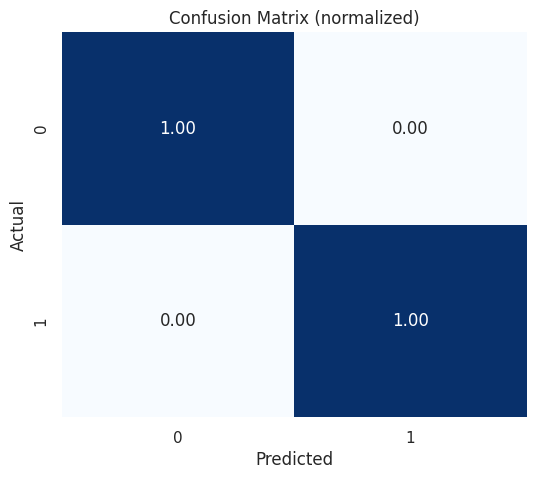

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#Confusion Matrix
y_true = load_substation['overload']
y_pred = load_substation['pred_overload']

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalizzata per riga

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (counts)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (normalized)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 ## 15. Operational Insights

The final analysis focuses on understanding the frequency of overload conditions and estimating future overload risk based on historical model predictions.

This provides a practical interpretation of the predictive model in an energy management context.

In [75]:
#Historical Overload Analysis.
#We analyze the number of real overload and near-overload situations observed in the dataset.

n_overloads_real = load_substation['overload'].sum()
n_near_overloads = load_substation['near_overload'].sum()

print(f'Real overloads in the dataset: {n_overloads_real}')
print(f'Near-overload situations in the dataset: {n_near_overloads}')

Real overloads in the dataset: 1102
Near-overload situations in the dataset: 1482


In [76]:
# Predicted Overloads
#The model predictions are used to estimate the number of overload scenarios identified by the classifier.
n_overloads_pred = load_substation['pred_overload'].sum()
print(f'Predicted Overloads: {n_overloads_pred}')

Predicted Overloads: 1103


In [78]:
#Future Overload Estimation
#Using the historical overload prediction rate, an estimate of expected overload events for the next year is calculated.
#This provides a simplified scenario analysis for future grid stress conditions.

n_hours_next_year = 8760  # hours in one year
pred_rate = n_overloads_pred / len(load_substation)  # prediction rate
expected_overloads_next_year = int(n_hours_next_year * pred_rate)
print(f'Expected overloads next year: {expected_overloads_next_year}')

Expected overloads next year: 439
